# Week 6: Transformer Attention and Rotary Position Encoding

This notebook builds attention from scratch, contrasts traditional positional encoding with rotary positional encoding (`RoPE`), and assembles a reusable Transformer block with both self-attention and cross-attention.

## Learning Goals
- Understand scaled dot-product attention and the role of `Query`, `Key`, and `Value`.
- Compare traditional additive positional encoding with rotary positional encoding.
- Build a Transformer block with residual connections, layer normalization, self-attention, and feed-forward layers.
- Extend the same block with cross-attention.
- Visualize attention weights in color so we can inspect where information flows.
- Reuse the saved IMDb tokenized dataset for a small Transformer encoder classifier setup.

## Reused Assets and Small Demo Data
This week reuses the saved IMDb tokenized assets from the previous weeks so the modeling comparison stays consistent.

- `../week5-CNN-for-text/data/imdb_bpe_dataset.pt`
- `../week5-CNN-for-text/data/bpe_vocab.json`
- `../week5-CNN-for-text/models/vocab_config.json`

For cross-attention, we also use a tiny handwritten paired-text probe so we can demonstrate encoder-decoder style attention without needing a full seq2seq dataset yet.

## Suggested Multi-Day Flow
- **Day 1:** Build intuition for scaled dot-product self-attention and inspect a heatmap.
- **Day 2:** Compare traditional positional encoding with rotary positional encoding (`RoPE`).
- **Day 3:** Assemble a Transformer block with residual connections, layer norm, and feed-forward layers.
- **Day 4:** Add cross-attention and test it on a tiny handwritten paired-text probe.
- **Day 5:** Reuse the same components for a compact IMDb Transformer encoder classifier.

You can treat each day as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from utils import (
    MultiHeadAttention,
    TinyTransformerClassifier,
    TransformerBlock,
    apply_rope,
    batch_encode_word_sequences,
    build_rope_cache,
    build_word_vocab,
    get_device,
    load_json,
    load_torch_dataset,
    plot_attention_heads,
    plot_attention_heatmap,
    scaled_dot_product_attention,
    sinusoidal_position_encoding,
    train_binary_classifier,
)


In [2]:
paths = {
    "dataset": Path("../week5-CNN-for-text/data/imdb_bpe_dataset.pt"),
    "bpe_vocab": Path("../week5-CNN-for-text/data/bpe_vocab.json"),
    "vocab_config": Path("../week5-CNN-for-text/models/vocab_config.json"),
    "dan_state": Path("../week5-CNN-for-text/models/dan_imdb.pt"),
}

missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Week 6 assets:\n" + "\n".join(missing))

input_ids, labels, attention_masks = load_torch_dataset(str(paths["dataset"]))
bpe_vocab = load_json(str(paths["bpe_vocab"]))
vocab_config = load_json(str(paths["vocab_config"]))
id_to_token = {idx: token for token, idx in bpe_vocab.items()}
device = get_device()

print("device:", device)
print("input_ids shape:", tuple(input_ids.shape))
print("labels shape:", tuple(labels.shape))
print("attention_masks shape:", tuple(attention_masks.shape))
print("vocab size:", vocab_config["vocab_size"])
print("pad id:", vocab_config["pad_id"])


device: mps
input_ids shape: (50000, 128)
labels shape: (50000,)
attention_masks shape: (50000, 128)
vocab size: 590
pad id: 589


## Day 1: Attention Foundations
The goal for Day 1 is to understand what attention is doing mechanically before we add position information or stack multiple sublayers.

### Self-Attention Intuition
A self-attention layer lets each token build a weighted summary of the other tokens in the same sequence. The weights come from similarity between `query` and `key`, while the content being aggregated comes from `value`. In matrix form, scaled dot-product self-attention is

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

where `Q`, `K`, and `V` all come from the same token sequence in the self-attention case.

For the first demo, we reuse the learned Week 5 `DAN` embedding weights so the token representations are not random. We also start with a projection-free version where `Q = K = V = token states` and call `scaled_dot_product_attention` directly, because the attention heatmap should visualize the attention weights themselves before we add learned projection layers in later cells.

This first visualization uses a single attention head only. We do not split the `384`-dimensional token state into multiple heads yet, so the extra head axis in the tensor shape is just a size-1 placeholder to match the attention function API. Multi-head splitting comes later.

This first self-attention demo also has no positional information at all. The attention scores depend only on content similarity between token vectors, not on token order or distance, which is exactly why we need positional encoding in the next section.

Because this demo does not use trained `Q`, `K`, or `V` projection layers, the attention scores are based directly on similarities between the fixed Week 5 token embeddings. In that sense, this first heatmap is mostly showing scaled static embedding similarity, not a learned attention pattern.

One easy-to-miss detail: even when a token is compared with itself, its final attention weight is not automatically `1`. Scaling divides every score in the row by the same `sqrt(d)` factor, and then softmax normalizes that token's self-score together with all of its scores against the other tokens. So a diagonal entry is only close to `1` if that self-score is much larger than the rest of the row.

Important caution: even with a learned embedding matrix, this is still not a trained attention layer. The displayed attention weights come from raw dot products on the current token states, so the heatmap is useful for understanding the mechanics of scaling, masking, and weighted averaging, but it should not be trusted as a meaningful explanation of what the model has learned. Once we introduce random `Q`, `K`, and `V` projection layers later, the heatmap becomes even less semantically interpretable until training has happened.

When the same sequence produces `Q`, `K`, and `V`, we call it **self-attention**.


sample tokens: ['82', '101', '116', '117114', '110</w>', '116', '111</w>', '67', '9798', '105110</w>', '98', '121</w>']
token states: (1, 12, 384)
query shape: (1, 1, 12, 384)
key shape: (1, 1, 12, 384)
value shape: (1, 1, 12, 384)
attention scores: (1, 1, 12, 12)
attention weights: (1, 1, 12, 12)
attention output: (1, 1, 12, 384)
head 0, first query weights: tensor([0.8195, 0.0221, 0.0131, 0.0148, 0.0208, 0.0131, 0.0113, 0.0168, 0.0184,
        0.0140, 0.0207, 0.0154])


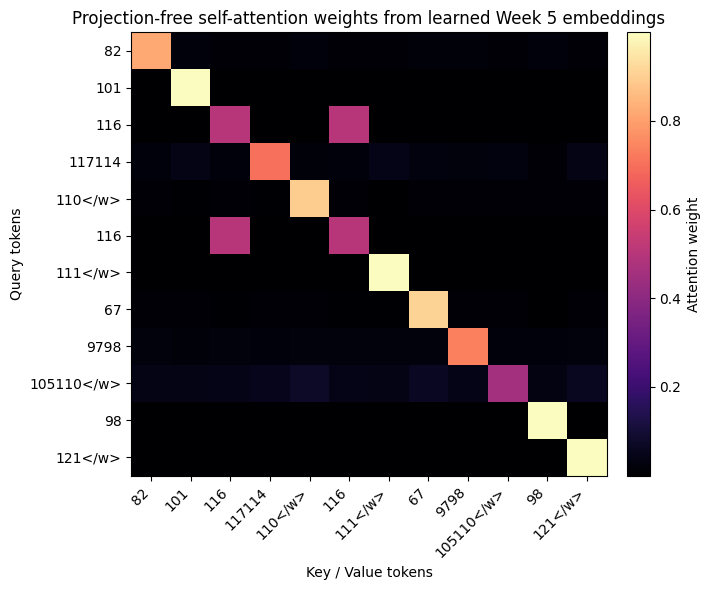

In [3]:
dan_state = torch.load(paths["dan_state"], map_location=device, weights_only=True)
embedding_weight = dan_state["embedding.weight"].to(device)
embedding_dim = embedding_weight.size(1)

# Pick one real IMDb example and trim to a short non-pad prefix for visualization.
sample_index = 204
sample_length = int(attention_masks[sample_index].sum().item())
display_len = min(12, sample_length)
sample_ids = input_ids[sample_index : sample_index + 1, :display_len].to(device)
sample_mask = attention_masks[sample_index : sample_index + 1, :display_len].to(device)
sample_tokens = [id_to_token[int(token_id)] for token_id in sample_ids[0].tolist()]

token_states = embedding_weight[sample_ids]
query = token_states.unsqueeze(1)
key = token_states.unsqueeze(1)
value = token_states.unsqueeze(1)
attention_mask = sample_mask.to(dtype=torch.bool).unsqueeze(1).unsqueeze(1)

attention_output, attention_weights = scaled_dot_product_attention(
    query=query,
    key=key,
    value=value,
    attention_mask=attention_mask,
    dropout_p=0.0,
    training=False,
)

score_scale = embedding_dim ** -0.5
attention_scores = torch.matmul(query, key.transpose(-2, -1)) * score_scale
attention_scores = attention_scores.masked_fill(~attention_mask, torch.finfo(attention_scores.dtype).min)

print("sample tokens:", sample_tokens)
print("token states:", tuple(token_states.shape))
print("query shape:", tuple(query.shape))
print("key shape:", tuple(key.shape))
print("value shape:", tuple(value.shape))
print("attention scores:", tuple(attention_scores.shape))
print("attention weights:", tuple(attention_weights.shape))
print("attention output:", tuple(attention_output.shape))
print("head 0, first query weights:", attention_weights[0, 0, 0].detach().cpu())

plot_attention_heatmap(
    attention_weights,
    sample_tokens,
    key_tokens=None,
    title="Projection-free self-attention weights from learned Week 5 embeddings",
    head=0,
    batch_idx=0,
)


## Day 2: Position Information
Now that the attention mechanism itself is clear, the next question is how the model knows token order. We start with the original additive approach and then move to rotary encoding.

### Traditional Positional Encoding
The original Transformer adds a position vector to the token embedding once near the input. This lets the model know where a token is, but the positional information is injected additively rather than directly modifying the attention geometry in every block.

The sinusoidal positional encoding used in the original paper is

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right), \qquad
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

where `pos` is the token position and `i` indexes pairs of embedding dimensions. The full input to the model is then formed by adding token embeddings and positional encodings:

$$
x_{pos} = e_{pos} + PE(pos)
$$


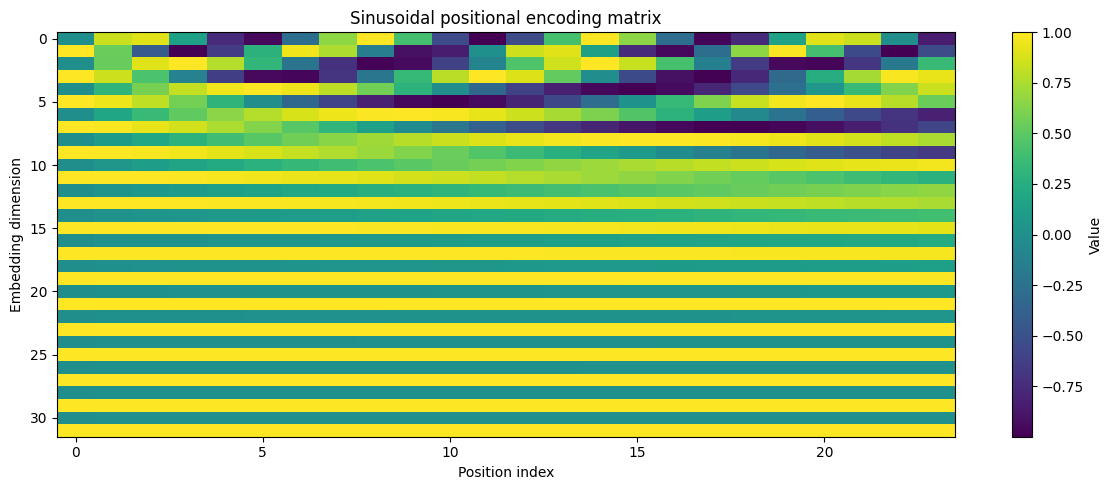

In [4]:
pe = sinusoidal_position_encoding(seq_len=24, d_model=32)

plt.figure(figsize=(12, 5))
plt.imshow(pe.T, aspect="auto", cmap="viridis")
plt.colorbar(label="Value")
plt.xlabel("Position index")
plt.ylabel("Embedding dimension")
plt.title("Sinusoidal positional encoding matrix")
plt.tight_layout()
plt.show()


### Rotary Positional Encoding (`RoPE`)
`RoPE` rotates pairs of dimensions inside the query and key vectors. This means position is injected inside the attention calculation itself rather than only once after the embedding layer.

For each position `p` and frequency index `i`, RoPE uses an angle

$$
\theta_{p,i} = p \cdot 10000^{-2i / d}
$$

and rotates each 2D pair of coordinates according to

$$
\begin{bmatrix}
x_{2i}^{\prime} \\ 
x_{2i+1}^{\prime}
\end{bmatrix}
=
\begin{bmatrix}
\cos \theta_{p,i} & -\sin \theta_{p,i} \\ 
\sin \theta_{p,i} & \cos \theta_{p,i}
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\ 
x_{2i+1}
\end{bmatrix}
$$

In the notebook code, this is implemented with

$$
\mathrm{RoPE}(x) = x \odot \cos(\theta) + \mathrm{rotate\_half}(x) \odot \sin(\theta)
$$

That rotation is useful because it preserves vector magnitudes and angles within each 2D subspace while making dot products depend on relative offsets between positions. This is one reason rotary encoding is widely used in modern Transformer and LLM architectures.


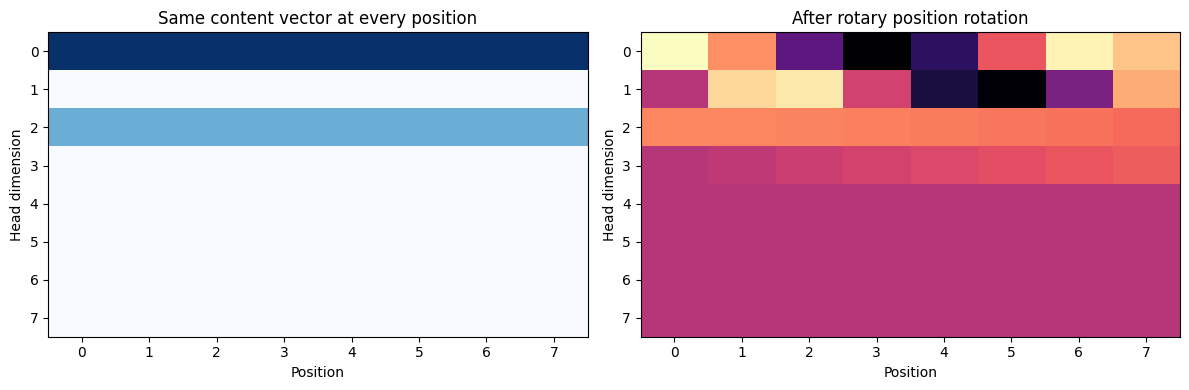

In [5]:
base_vector = torch.zeros(1, 1, 8, 8)
base_vector[..., 0] = 1.0
base_vector[..., 2] = 0.5

cos, sin = build_rope_cache(seq_len=8, head_dim=8)
rotated = apply_rope(base_vector, cos, sin)[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(base_vector[0, 0].T, aspect="auto", cmap="Blues")
axes[0].set_title("Same content vector at every position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Head dimension")

axes[1].imshow(rotated.T, aspect="auto", cmap="magma")
axes[1].set_title("After rotary position rotation")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Head dimension")

plt.tight_layout()
plt.show()


## Day 3: Building the Transformer Block
With attention and position handling in place, we can package the pieces into the standard block structure used throughout encoder and decoder stacks.

### Residual Connections and the Transformer Block
A residual connection means the block learns an update to the existing representation instead of replacing it completely. In practice we add the sublayer output back to the input:

- `x = x + self_attention(...)`
- `x = x + feed_forward(...)`

This helps optimization and preserves useful information from earlier layers.

In [ ]:
torch.manual_seed(204)

batch_size = 2
seq_len = 96
d_model = 64
num_heads = 4

sample_ids = input_ids[:batch_size, :seq_len].to(device)
sample_masks = attention_masks[:batch_size, :seq_len].to(device)

embedding = nn.Embedding(vocab_config["vocab_size"], d_model, padding_idx=vocab_config["pad_id"]).to(device)
sample_states = embedding(sample_ids)

transformer_block = TransformerBlock(
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=128,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=False,
).to(device)

block_output, block_attentions = transformer_block(
    x=sample_states,
    attention_mask=sample_masks,
    return_attentions=True,
)

print("embedded batch:", tuple(sample_states.shape))
print("block output:", tuple(block_output.shape))
print("self-attention tensor:", tuple(block_attentions["self_attention"].shape))


## Day 4: Cross-Attention with a Tiny Probe
Cross-attention needs two sequences with different roles: one sequence provides information, and the other sequence asks what to focus on. Since IMDb is not naturally paired text, we introduce a tiny handwritten probe here.

### Tiny Paired-Text Probe for Cross-Attention
IMDb is naturally a single-sequence classification dataset, so it is ideal for self-attention. For cross-attention we create a tiny paired-text probe similar in spirit to the handwritten benchmark sets from Weeks 4 and 5.

Each example has:
- a **context** sequence that provides information
- a **query** sequence that asks what to look for

That is the basic encoder-decoder pattern behind cross-attention.

In [ ]:
toy_pairs = [
    {
        "context": "the acting was fantastic but the ending was weak",
        "query": "what was positive ?",
    },
    {
        "context": "the plot was dull but the soundtrack was memorable",
        "query": "what was positive ?",
    },
    {
        "context": "the movie is not bad",
        "query": "what phrase flips sentiment ?",
    },
    {
        "context": "only the final scene is good",
        "query": "what carries the praise ?",
    },
]

all_texts = [item["context"] for item in toy_pairs] + [item["query"] for item in toy_pairs]
toy_word_vocab = build_word_vocab(all_texts)

context_ids, context_masks, context_tokens = batch_encode_word_sequences(
    [item["context"] for item in toy_pairs],
    vocab=toy_word_vocab,
    max_len=12,
)
query_ids, query_masks, query_tokens = batch_encode_word_sequences(
    [item["query"] for item in toy_pairs],
    vocab=toy_word_vocab,
    max_len=6,
)

print("context batch:", tuple(context_ids.shape))
print("query batch:", tuple(query_ids.shape))
print("toy vocab size:", len(toy_word_vocab))


### Hand-Crafted Cross-Attention Visualization
Before training any model, we can create a tiny hand-crafted semantic example so the heatmap is interpretable. The query token `positive` is given a vector that aligns with the context token `fantastic`, and the query token `weak` aligns with `weak` in the context.

In [ ]:
context_demo_tokens = ["acting", "fantastic", "ending", "weak"]
query_demo_tokens = ["positive", "weak"]

semantic_vectors = {
    "acting": torch.tensor([0.4, 0.1, 0.0, 0.0]),
    "fantastic": torch.tensor([1.0, 0.0, 0.0, 0.0]),
    "ending": torch.tensor([0.0, 0.2, 0.3, 0.0]),
    "weak": torch.tensor([0.0, 1.0, 0.0, 0.0]),
    "positive": torch.tensor([1.0, 0.0, 0.0, 0.0]),
}

context_states = torch.stack([semantic_vectors[token] for token in context_demo_tokens], dim=0).unsqueeze(0).unsqueeze(0)
query_states = torch.stack([semantic_vectors[token] for token in query_demo_tokens], dim=0).unsqueeze(0).unsqueeze(0)
values = context_states.clone()

manual_cross_output, manual_cross_attention = scaled_dot_product_attention(
    query=query_states,
    key=context_states,
    value=values,
)

print("manual cross-attention output shape:", tuple(manual_cross_output.shape))
plot_attention_heatmap(
    manual_cross_attention,
    query_tokens=query_demo_tokens,
    key_tokens=context_demo_tokens,
    title="Hand-crafted cross-attention heatmap",
    head=0,
)


### Cross-Attention Block API
Now we run the reusable `TransformerBlock` in cross-attention mode. Because the block is randomly initialized, the heatmaps are mostly about shape and mechanics rather than learned semantics.

In [ ]:
torch.manual_seed(11)

toy_embed = nn.Embedding(len(toy_word_vocab), 32).to(device)
context_states = toy_embed(context_ids.to(device))
query_states = toy_embed(query_ids.to(device))

cross_block = TransformerBlock(
    d_model=32,
    num_heads=4,
    mlp_hidden_dim=64,
    dropout=0.0,
    use_rope=True,
    enable_cross_attention=True,
).to(device)

cross_output, cross_attentions = cross_block(
    x=query_states,
    attention_mask=query_masks.to(device),
    context=context_states,
    context_mask=context_masks.to(device),
    return_attentions=True,
)

example_idx = 0
valid_q = int(query_masks[example_idx].sum().item())
valid_k = int(context_masks[example_idx].sum().item())
example_attention = cross_attentions["cross_attention"][example_idx:example_idx + 1, :, :valid_q, :valid_k].detach().cpu()

print("cross output shape:", tuple(cross_output.shape))
print("self-attention on query shape:", tuple(cross_attentions["self_attention"].shape))
print("cross-attention shape:", tuple(cross_attentions["cross_attention"].shape))
plot_attention_heads(
    example_attention,
    query_tokens=query_tokens[example_idx][:valid_q],
    key_tokens=context_tokens[example_idx][:valid_k],
    max_heads=4,
)


## Day 5: IMDb Mini-Project
The final step is to bring the reusable attention components back to the main course dataset. This section keeps the experiment intentionally small so the notebook remains approachable.

### Tiny Transformer Encoder for IMDb
We can now reuse the same building blocks for encoder-style sentiment classification on IMDb. Below we create one shared IMDb subset and compare two compact Transformer encoders.

- Model A: traditional sinusoidal positional encoding added after embeddings
- Model B: rotary positional encoding (`RoPE`) applied inside attention

To keep the notebook light, we use a small subset for the demo path. If you want a more serious experiment, increase the subset sizes and number of epochs.

### Same Dataset, Same Split, Different Positional Strategy
For a fair comparison, both models should use the exact same IMDb subset, the same train/validation split, and the same core hyperparameters. The only intentional difference should be how position information is injected.

In [ ]:
subset_size = 3072
dataset = TensorDataset(
    input_ids[:subset_size],
    attention_masks[:subset_size],
    labels[:subset_size].float(),
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(204),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

shared_model_kwargs = dict(
    vocab_size=vocab_config["vocab_size"],
    d_model=128,
    num_heads=4,
    mlp_hidden_dim=256,
    num_layers=2,
    pad_id=vocab_config["pad_id"],
    dropout=0.1,
    max_seq_len=input_ids.size(1),
)

torch.manual_seed(204)
absolute_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=False,
    use_absolute_positions=True,
).to(device)

torch.manual_seed(204)
rope_model = TinyTransformerClassifier(
    **shared_model_kwargs,
    use_rope=True,
    use_absolute_positions=False,
).to(device)

batch_ids, batch_masks, batch_labels = next(iter(train_loader))
absolute_logits, absolute_attention_stack = absolute_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)
rope_logits, rope_attention_stack = rope_model(
    batch_ids.to(device),
    batch_masks.to(device),
    return_attention=True,
)

print("shared subset size:", len(dataset))
print("train / val sizes:", len(train_dataset), len(val_dataset))
print("absolute logits shape:", tuple(absolute_logits.shape))
print("rope logits shape:", tuple(rope_logits.shape))
print("absolute attention layers:", len(absolute_attention_stack))
print("rope attention layers:", len(rope_attention_stack))
print("absolute layer-0 attention shape:", tuple(absolute_attention_stack[0].shape))
print("rope layer-0 attention shape:", tuple(rope_attention_stack[0].shape))


In [ ]:
# Optional apples-to-apples training run
# torch.manual_seed(204)
# absolute_model = TinyTransformerClassifier(
#     **shared_model_kwargs,
#     use_rope=False,
#     use_absolute_positions=True,
# ).to(device)
# torch.manual_seed(204)
# rope_model = TinyTransformerClassifier(
#     **shared_model_kwargs,
#     use_rope=True,
#     use_absolute_positions=False,
# ).to(device)
#
# absolute_model = train_binary_classifier(
#     model=absolute_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     num_epochs=3,
#     lr=3e-4,
#     patience=2,
# )
#
# rope_model = train_binary_classifier(
#     model=rope_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     device=device,
#     num_epochs=3,
#     lr=3e-4,
#     patience=2,
# )


## Wrap-Up
At this point we have:
- a reusable multi-head attention module
- rotary and sinusoidal positional encoding utilities
- a Transformer block with residual connections
- a cross-attention extension
- attention heatmaps for visual inspection
- a compact IMDb Transformer encoder setup

If you want to stretch this further, a good next exercise is to train two tiny IMDb models with the same hyperparameters: one using absolute positional encoding and one using `RoPE`, then compare validation behavior and attention maps.

This gives us a strong bridge into Week 7, where pretraining and transfer learning become the main story.